In [9]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
import statistics
import pandas as pd
from scipy import stats
from scipy.stats import gaussian_kde

In [10]:
time_s1_p1 = []
time_s1_p2 = []
time_s1_p3 = []
time_s1_p4 = []
time_s2_p1 = []
time_s2_p2 = []
time_s2_p3 = []
time_s2_p4 = []

In [29]:
Nr = 50
nbins = 40
time = np.zeros(Nr)
# sig = 13.11
sig = np.sqrt(13.11*2)
dt = 0.01

# Room size
W = [0, 7.3]
L = [0, 5.5]

# Furnature
C_1 = 0.75 # C_1
R_1 = [1.8, 0.45] #R_1
R_2 = [3, 0.9] # R_2
R_3 = [0.9, 3] #R_3

In [30]:
def plot_path(xdata, ydata, taret_x, target_y):
    # Plot 
    plt.figure(figsize=(5,5))

    # Target
    theta = np.linspace(0, 2*np.pi, 100)
    x_circle = taret_x + 0.3 * np.cos(theta)
    y_circle = target_y + 0.3 * np.sin(theta)
    plt.plot(x_circle, y_circle, color='red', linestyle=':', linewidth=2, label='Target')

    # C_1
    theta = np.linspace(0, 2*np.pi, 100)
    x_circle_1 = 1.25 + 0.75 * np.cos(theta)
    y_circle_1 = 1.25 + 0.75 * np.sin(theta)
    plt.plot(x_circle_1, y_circle_1, color='blue', linestyle=':', linewidth=2, label='Target')

    # R_1
    r_1_x = [0.7, 2.4, 2.4, 0.7, 0.7]
    r_1_y = [5.05, 5.05, 5.5, 5.5, 5.05]
    plt.plot(r_1_x, r_1_y, color='blue', linewidth=2, linestyle=':')

    # R_2
    r_2_x = [0, 3.0, 3.0, 0, 0]
    r_2_y = [3.15, 3.15, 4.05, 4.05, 3.15]
    plt.plot(r_2_x, r_2_y, color='blue', linewidth=2, linestyle=':')

    # R_3
    r_3_x = [4.9, 5.8, 5.8, 4.9, 4.9]
    r_3_y = [1.0, 1.0, 4.0, 4.0, 1.0]
    plt.plot(r_3_x, r_3_y, color='blue', linewidth=2, linestyle=':')

    # R_Room
    plt.plot([0, 7.3, 7.3, 0, 0], [0, 0, 5.5, 5.5, 0], color='black', linewidth=1.5)

    # Path
    plt.plot(xdata, ydata, color='green', linewidth=1)

    # Starting point 
    plt.plot(xdata[0], ydata[0], color="orange", linewidth=5, marker='o')

    # End point
    plt.plot(xdata[-1], ydata[-1], color="orange", linewidth=5, marker='o')

    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()
    return None

In [33]:
def simulate_s1_random_walking_path(target_x, target_y):
    # Wallet location 
    r = 0.3

    # Save the first trajectory 
    xdata = []
    ydata = []

    for k in range(Nr):
        # Initial position
        x = 7.2
        y = 5.4
        t = 0 # Reset the time 

        # Initialize the starting location 
        if k==1:
            xdata.append(x)
            ydata.append(y)

        # Do random walk 
        while (x-target_x)**2 + (y-target_y)**2 > r**2:
            x1 = x + sig*np.random.randn()*np.sqrt(dt)
            y1 = y + sig*np.random.randn()*np.sqrt(dt)

            # Conditions 
            Check_room = (W[0] <= x1 <= W[1]) and (L[0] <= y1 <= L[1])
            Check_C1= (x1-1.25)**2 + (y1-1.25)**2 > C_1**2
            Check_R1 = not (0.6 <= x1 <= 2.4 and 5.05 <= y1 <= 5.5)
            Check_R2 = not (0 <= x1 < 3 and 3.15 < y1 < 4.05)
            Check_R3 = not (4.9 <= x1 < 5.8 and 1 <= y1 < 4)

            # Do something while hit the boundary 
            if Check_room and Check_C1 and Check_R1 and Check_R2 and Check_R3:
                x = x1
                y = y1

            # Save the path 
            if k==1:
                xdata.append(x)
                ydata.append(y)
            t += dt 

        time[k] = t

    plot_path(xdata, ydata, target_x, target_y)
    return time

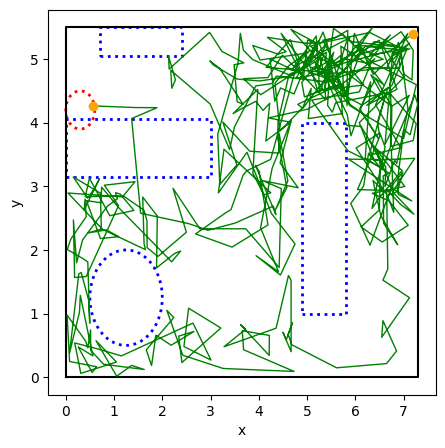

In [34]:
time_s1_p1 = simulate_s1_random_walking_path(0.3, 4.2)

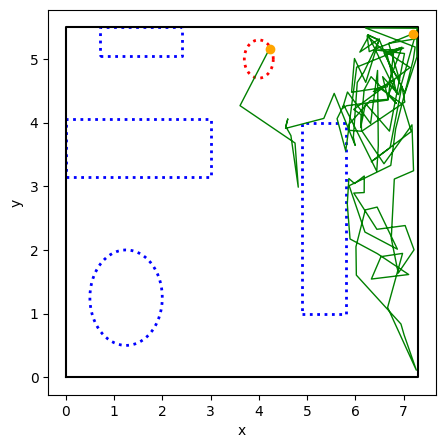

In [38]:
time_s1_p1 = simulate_s1_random_walking_path(4, 5)